In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushikyad001/water-pollution-and-disease")

print("Path to dataset files:", path)

c:\Users\HP\Downloads\aiml\Water-borne-disease-outbreak-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\khushikyad001\water-pollution-and-disease\versions\1


In [3]:
print("Dataset downloaded to:", path)

# Check what files are inside
print("Files inside folder:", os.listdir(path))

# Find the actual CSV file in the downloaded folder
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]
if not csv_files:
	raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

print("Shape of dataset:", df.shape)
print(df.head())

Dataset downloaded to: C:\Users\HP\.cache\kagglehub\datasets\khushikyad001\water-pollution-and-disease\versions\1
Files inside folder: ['water_pollution_disease.csv']
Shape of dataset: (3000, 24)
     Country   Region  Year Water Source Type  Contaminant Level (ppm)  \
0     Mexico    North  2015              Lake                     6.06   
1     Brazil     West  2017              Well                     5.24   
2  Indonesia  Central  2022              Pond                     0.24   
3    Nigeria     East  2016              Well                     7.91   
4     Mexico    South  2005              Well                     0.12   

   pH Level  Turbidity (NTU)  Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  \
0      7.12             3.93                     4.28                  8.28   
1      7.84             4.79                     3.86                 15.74   
2      6.43             0.79                     3.42                 36.67   
3      6.71             1.96               

In [4]:

# Step 1: Standardize column names
df['Country'] = df['Country'].str.strip().str.lower()
df['Region'] = df['Region'].str.strip().str.lower()

# Step 2: Keep only India + Region = East
east_df = df[(df['Country'] == 'india') & (df['Region'] == 'east')].copy()

# Step 3: Drop duplicates
east_df = east_df.drop_duplicates()

# Step 4: Handle missing values
for col in east_df.select_dtypes(include=['float64','int64']).columns:
    east_df[col] = east_df[col].fillna(east_df[col].median())

for col in east_df.select_dtypes(include=['object']).columns:
    east_df[col] = east_df[col].fillna("unknown")

print("East Region Cleaned Data Shape:", east_df.shape)
print("Years covered:", east_df['Year'].unique())

# Save cleaned dataset
east_df.to_csv("east_region_india_water_disease_cleaned.csv", index=False)


East Region Cleaned Data Shape: (65, 24)
Years covered: [2002 2024 2006 2004 2005 2015 2013 2003 2011 2022 2012 2008 2001 2016
 2020 2009 2021 2014 2007 2010 2019 2017 2018 2000]


C:\Users\HP\AppData\Local\Temp\ipykernel_26156\3044615768.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in east_df.select_dtypes(include=['object']).columns:


Shape of dataset: (65, 24)

Columns: ['Country', 'Region', 'Year', 'Water Source Type', 'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)', 'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)', 'Water Treatment Method', 'Access to Clean Water (% of Population)', 'Diarrheal Cases per 100,000 people', 'Cholera Cases per 100,000 people', 'Typhoid Cases per 100,000 people', 'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)', 'Healthcare Access Index (0-100)', 'Urbanization Rate (%)', 'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)', 'Temperature (°C)', 'Population Density (people per km²)']

Summary statistics:
               Year  Contaminant Level (ppm)   pH Level  Turbidity (NTU)  \
count    65.000000                65.000000  65.000000        65.000000   
mean   2010.446154                 4.761385   7.252769         2.446000   
std       7.130548                 2.907033   0.796456        

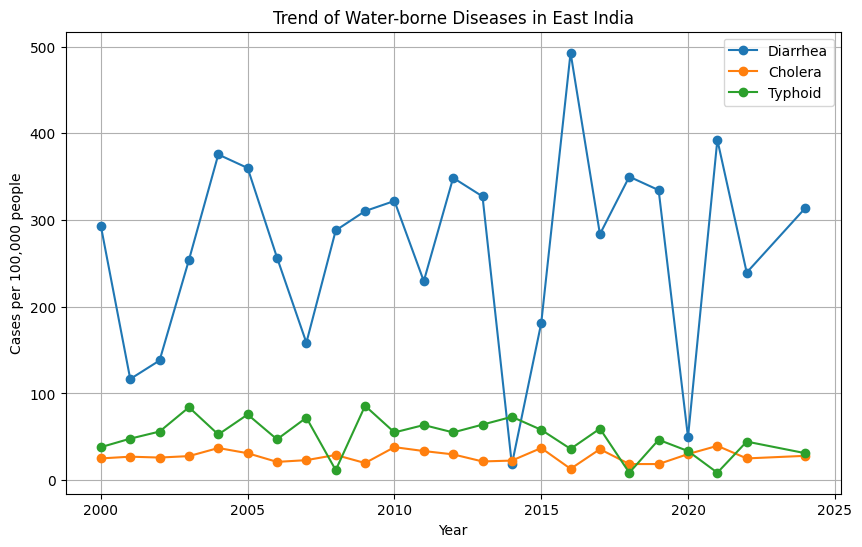


Infrastructure & Health Indicators:
       Access to Clean Water (% of Population)  \
Year                                            
2000                                35.010000   
2001                                59.778000   
2002                                70.390000   
2003                                89.976667   
2004                                72.156000   
2005                                70.066667   
2006                                43.823333   
2007                                66.665000   
2008                                79.315000   
2009                                85.673333   
2010                                50.440000   
2011                                87.825000   
2012                                58.333333   
2013                                68.547500   
2014                                52.260000   
2015                                83.520000   
2016                                31.800000   
2017                           

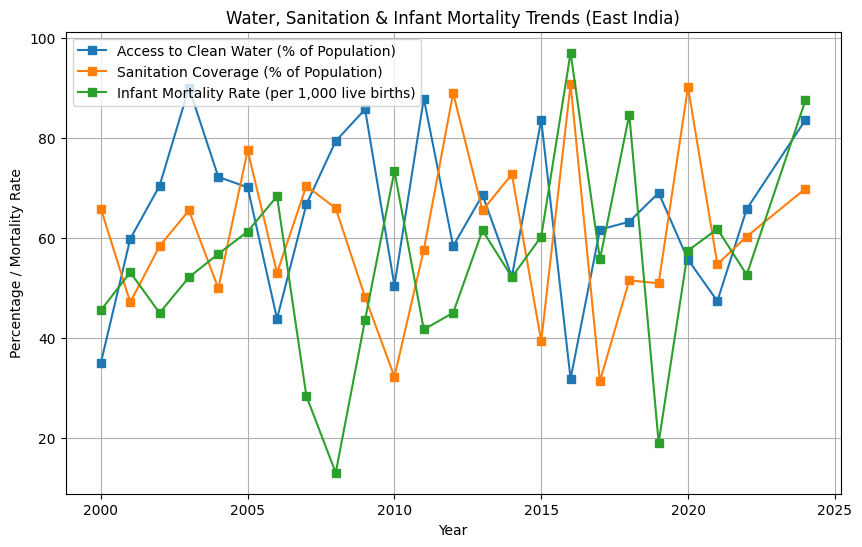


Correlation of Water Quality vs Diseases:
                                     Diarrheal Cases per 100,000 people  \
Contaminant Level (ppm)                                           0.11   
pH Level                                                         -0.07   
Turbidity (NTU)                                                  -0.08   
Nitrate Level (mg/L)                                             -0.06   
Lead Concentration (µg/L)                                         0.06   
Bacteria Count (CFU/mL)                                          -0.13   
Diarrheal Cases per 100,000 people                                1.00   
Cholera Cases per 100,000 people                                  0.08   
Typhoid Cases per 100,000 people                                 -0.11   

                                    Cholera Cases per 100,000 people  \
Contaminant Level (ppm)                                        -0.02   
pH Level                                                        0.10   

In [5]:

# Load cleaned dataset (East region)
df = pd.read_csv("east_region_india_water_disease_cleaned.csv")

# ==============================
# 1. Basic Dataset Information
# ==============================
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSummary statistics:\n", df.describe())

# ==============================
# 2. Disease Trend by Year
# ==============================
disease_trend = df.groupby("Year")[
    ["Diarrheal Cases per 100,000 people",
     "Cholera Cases per 100,000 people",
     "Typhoid Cases per 100,000 people"]
].mean()

print("\nAverage Disease Cases by Year:\n", disease_trend)

# Plot disease trend
disease_trend.plot(figsize=(10,6), marker='o')
plt.title("Trend of Water-borne Diseases in East India")
plt.xlabel("Year")
plt.ylabel("Cases per 100,000 people")
plt.legend(["Diarrhea", "Cholera", "Typhoid"])
plt.grid(True)
plt.show()

# ==============================
# 3. Water & Sanitation Trends
# ==============================
infra_trend = df.groupby("Year")[
    ["Access to Clean Water (% of Population)",
     "Sanitation Coverage (% of Population)",
     "Infant Mortality Rate (per 1,000 live births)"]
].mean()

print("\nInfrastructure & Health Indicators:\n", infra_trend)

# Plot infra trend
infra_trend.plot(figsize=(10,6), marker='s')
plt.title("Water, Sanitation & Infant Mortality Trends (East India)")
plt.xlabel("Year")
plt.ylabel("Percentage / Mortality Rate")
plt.grid(True)
plt.show()

# ==============================
# 4. Correlation with Water Quality
# ==============================
corr = df[[
    "Contaminant Level (ppm)", "pH Level", "Turbidity (NTU)", 
    "Nitrate Level (mg/L)", "Lead Concentration (µg/L)", 
    "Bacteria Count (CFU/mL)",
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people"
]].corr()

print("\nCorrelation of Water Quality vs Diseases:\n", corr[[
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people"
]].round(2))


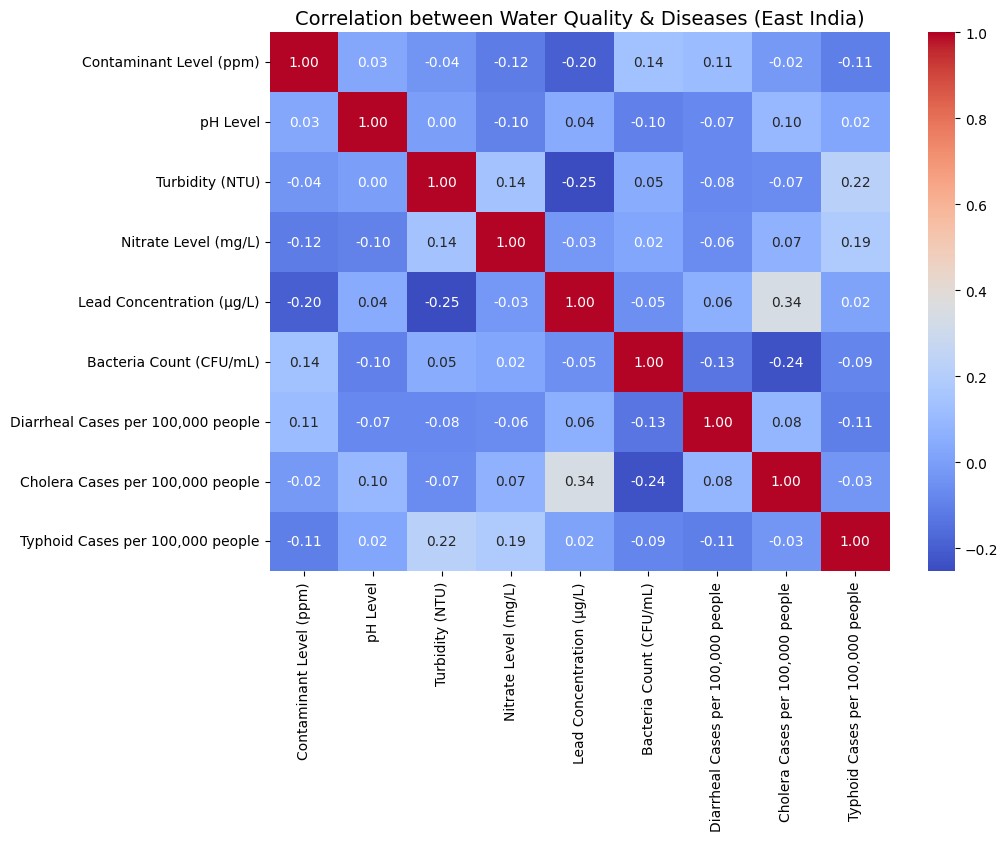

In [6]:
cols = [
    "Contaminant Level (ppm)", "pH Level", "Turbidity (NTU)", 
    "Nitrate Level (mg/L)", "Lead Concentration (µg/L)", 
    "Bacteria Count (CFU/mL)",
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people"
]

# Correlation matrix
corr = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation between Water Quality & Diseases (East India)", fontsize=14)
plt.show()

High vs Low Diarrhea Case Distribution:
Diarrhea_Group
Low     33
High    32
Name: count, dtype: int64

Water Parameter Comparison (High vs Low Diarrhea cases):
                 Turbidity (NTU)  Rainfall (mm per year)  \
Diarrhea_Group                                            
High                   2.338125             1330.375000   
Low                    2.550606             1668.757576   

                Contaminant Level (ppm)  Bacteria Count (CFU/mL)  \
Diarrhea_Group                                                     
High                           4.884688              2557.656250   
Low                            4.641818              2538.090909   

                Lead Concentration (µg/L)  
Diarrhea_Group                             
High                            11.132188  
Low                             10.287879  

Pearson Correlation Matrix (Water Quality vs Diseases):
                                     Contaminant Level (ppm)  pH Level  \
Contaminant Level (pp

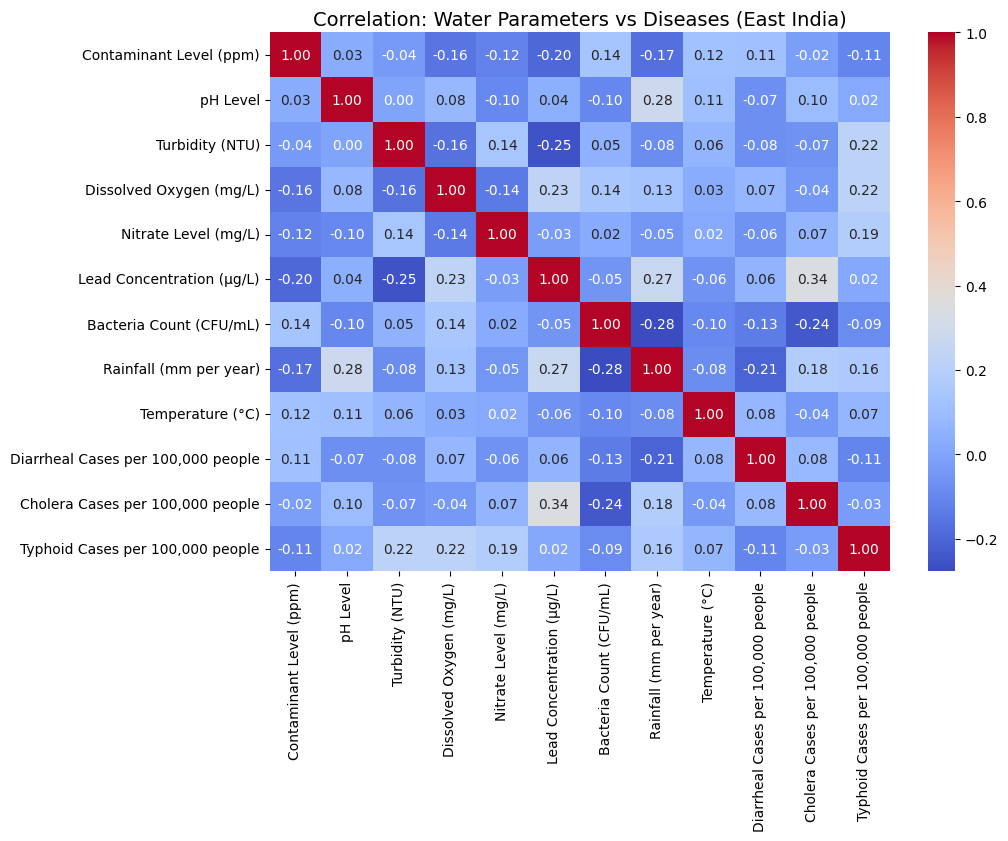


Spearman Correlation (Turbidity vs Diarrhea): -0.07, p=0.5891


In [7]:
from scipy.stats import spearmanr, pearsonr

# Load cleaned East region dataset
df = pd.read_csv("east_region_india_water_disease_cleaned.csv")

# ===========================
# 1. High vs Low Cases Split
# ===========================
# Example: Diarrhea
median_diarrhea = df["Diarrheal Cases per 100,000 people"].median()

df["Diarrhea_Group"] = df["Diarrheal Cases per 100,000 people"].apply(
    lambda x: "High" if x > median_diarrhea else "Low"
)

print("High vs Low Diarrhea Case Distribution:")
print(df["Diarrhea_Group"].value_counts())

# Compare averages of water parameters for high vs low diarrhea villages
group_comparison = df.groupby("Diarrhea_Group")[
    ["Turbidity (NTU)", "Rainfall (mm per year)", "Contaminant Level (ppm)",
     "Bacteria Count (CFU/mL)", "Lead Concentration (µg/L)"]
].mean()
print("\nWater Parameter Comparison (High vs Low Diarrhea cases):\n", group_comparison)

# ===========================
# 2. Correlation Analysis
# ===========================
corr = df[[
    "Contaminant Level (ppm)", "pH Level", "Turbidity (NTU)",
    "Dissolved Oxygen (mg/L)", "Nitrate Level (mg/L)",
    "Lead Concentration (µg/L)", "Bacteria Count (CFU/mL)",
    "Rainfall (mm per year)", "Temperature (°C)",
    "Diarrheal Cases per 100,000 people",
    "Cholera Cases per 100,000 people",
    "Typhoid Cases per 100,000 people"
]].corr(method="pearson")  # Pearson correlation

print("\nPearson Correlation Matrix (Water Quality vs Diseases):\n", corr.round(2))

# ===========================
# 3. Heatmap Visualization
# ===========================
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation: Water Parameters vs Diseases (East India)", fontsize=14)
plt.show()

# ===========================
# 4. Spearman Correlation (non-linear)
# ===========================
# Example: Turbidity vs Diarrhea
spearman_corr, p_value = spearmanr(df["Turbidity (NTU)"], df["Diarrheal Cases per 100,000 people"])
print(f"\nSpearman Correlation (Turbidity vs Diarrhea): {spearman_corr:.2f}, p={p_value:.4f}")



📊 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.50      0.50      0.50         2

    accuracy                           0.85        13
   macro avg       0.70      0.70      0.70        13
weighted avg       0.85      0.85      0.85        13

AUC: 0.7727272727272727

📊 Random Forest Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.00      0.00      0.00         2

    accuracy                           0.77        13
   macro avg       0.42      0.45      0.43        13
weighted avg       0.71      0.77      0.74        13

AUC: 0.5909090909090908

📊 XGBoost Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.00      0.00      0.00         2

    accuracy                           0.77        13
   ma

c:\Users\HP\Downloads\aiml\Water-borne-disease-outbreak-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:21:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


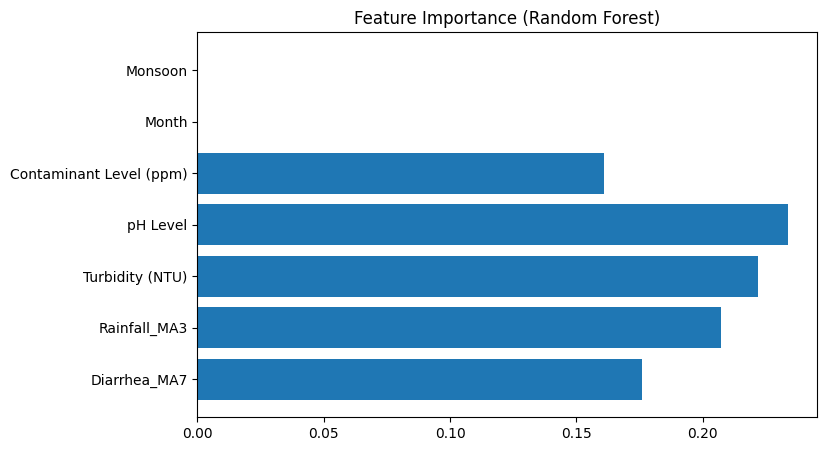

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("east_region_india_water_disease_cleaned.csv")

# =======================
# 1. Feature Engineering
# =======================

# Date index बनाना (मान लो Year column available है, वरना दिन-स्तर का data होना चाहिए)
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-01-01")

# Sort by date
df = df.sort_values("Date")

# Moving average (7-day cases) – यहाँ yearly data है, demo purpose पर rolling
df["Diarrhea_MA7"] = df["Diarrheal Cases per 100,000 people"].rolling(window=7, min_periods=1).mean()

# 3-day rainfall avg (simulated for demo, अगर daily data हो तो exact होगा)
df["Rainfall_MA3"] = df["Rainfall (mm per year)"].rolling(window=3, min_periods=1).mean()

# Season features
df["Month"] = df["Date"].dt.month
df["Monsoon"] = df["Month"].apply(lambda x: 1 if x in [6,7,8,9] else 0)

# Define outbreak (binary target)
threshold = df["Diarrheal Cases per 100,000 people"].quantile(0.75)
df["Outbreak"] = (df["Diarrheal Cases per 100,000 people"] > threshold).astype(int)

# =======================
# 2. Model Input/Output
# =======================
features = [
    "Diarrhea_MA7", "Rainfall_MA3", 
    "Turbidity (NTU)", "pH Level", "Contaminant Level (ppm)",
    "Month", "Monsoon"
]
X = df[features]
y = df["Outbreak"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================
# 3. Models
# =======================

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
print("\n📊 Logistic Regression Report:")
print(classification_report(y_test, log_preds))
print("AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("\n📊 Random Forest Report:")
print(classification_report(y_test, rf_preds))
print("AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("\n📊 XGBoost Report:")
print(classification_report(y_test, xgb_preds))
print("AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

# =======================
# 4. Feature Importance
# =======================
importances = rf_model.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


In [9]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load cleaned dataset (East region)
df = pd.read_csv("east_region_india_water_disease_cleaned.csv")

# -----------------------------
# 1. Prepare Data for Prophet
# -----------------------------
# Prophet expects columns: ds = datetime, y = target
# We'll forecast Diarrheal Cases
df['ds'] = pd.to_datetime(df['Year'].astype(str) + '-01-01')  # yearly data
df['y'] = df['Diarrheal Cases per 100,000 people']

# Sort by date
df = df.sort_values('ds')

# -----------------------------
# 2. Initialize and Fit Model
# -----------------------------
model = Prophet(yearly_seasonality=True)  # yearly seasonality
model.fit(df[['ds','y']])

# -----------------------------
# 3. Make Future Predictions
# -----------------------------
future = model.make_future_dataframe(periods=5, freq='Y')  # predict next 5 years
forecast = model.predict(future)

# -----------------------------
# 4. Plot Forecast
# -----------------------------
fig1 = model.plot(forecast)
plt.title("Forecast of Diarrheal Cases (East India)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Cases per 100,000 people")
plt.show()

# -----------------------------
# 5. Plot Components (Trend & Seasonality)
# -----------------------------
fig2 = model.plot_components(forecast)
plt.show()

# -----------------------------
# 6. Optional: Define Outbreak Risk Threshold
# -----------------------------
threshold = df['y'].quantile(0.75)
forecast['Outbreak_Risk'] = (forecast['yhat'] > threshold).astype(int)

print(forecast[['ds', 'yhat', 'Outbreak_Risk']].tail(10))  # last 10 rows


Importing plotly failed. Interactive plots will not work.
19:21:17 - cmdstanpy - INFO - Chain [1] start processing
19:21:18 - cmdstanpy - INFO - Chain [1] done processing


ValueError: Invalid frequency: Y. Failed to parse with error message: ValueError("'Y' is no longer supported for offsets. Please use 'YE' instead.")

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load cleaned East India dataset
df = pd.read_csv("east_region_india_water_disease_cleaned.csv")

# ==========================
# 1. Define outbreak thresholds
# ==========================
# Threshold = 75th percentile for each disease
df["Diarrhea_Outbreak"] = (df["Diarrheal Cases per 100,000 people"] > df["Diarrheal Cases per 100,000 people"].quantile(0.75)).astype(int)
df["Cholera_Outbreak"] = (df["Cholera Cases per 100,000 people"] > df["Cholera Cases per 100,000 people"].quantile(0.75)).astype(int)
df["Typhoid_Outbreak"] = (df["Typhoid Cases per 100,000 people"] > df["Typhoid Cases per 100,000 people"].quantile(0.75)).astype(int)

# ==========================
# 2. Feature Engineering
# ==========================
df["Diarrhea_MA7"] = df["Diarrheal Cases per 100,000 people"].rolling(7, min_periods=1).mean()
df["Rainfall_MA3"] = df["Rainfall (mm per year)"].rolling(3, min_periods=1).mean()
df["Month"] = 1  # Yearly data, dummy
df["Monsoon"] = 0

features = ["Diarrhea_MA7","Rainfall_MA3","Turbidity (NTU)","pH Level","Contaminant Level (ppm)","Month","Monsoon"]
X = df[features].fillna(0)
y = df[["Diarrhea_Outbreak","Cholera_Outbreak","Typhoid_Outbreak"]]

# ==========================
# 3. Train-Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 4. Train Multi-Output Random Forest
# ==========================
from sklearn.multioutput import MultiOutputClassifier
rf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf.fit(X_train_scaled, y_train)

# ==========================
# 5. Predict Function
# ==========================
def predict_outbreak(input_data):
    """
    input_data = dict with keys matching 'features'
    Returns: Outbreak probabilities for all 3 diseases
    """
    # Force correct column order
    df_input = pd.DataFrame([input_data])[features]
    df_scaled = scaler.transform(df_input)
    probs = rf.predict_proba(df_scaled)
    
    result = {
        "Diarrhea_Risk(%)": round(probs[0][0][1]*100,2),
        "Cholera_Risk(%)": round(probs[1][0][1]*100,2),
        "Typhoid_Risk(%)": round(probs[2][0][1]*100,2)
    }
    return result


# ==========================
# 6. Example usage
# ==========================
input_example = {
    "Diarrhea_MA7": 50,
    "Rainfall_MA3": 120,
    "Turbidity (NTU)": 6,
    "pH Level": 7.2,
    "Contaminant Level (ppm)": 3.5,
    "Month": 7,
    "Monsoon": 1
}

risk = predict_outbreak(input_example)
print("Predicted Outbreak Risk (%):", risk)



Predicted Outbreak Risk (%): {'Diarrhea_Risk(%)': np.float64(14.0), 'Cholera_Risk(%)': np.float64(21.0), 'Typhoid_Risk(%)': np.float64(10.0)}
